# Mortalidade por Violência contra Mulheres no Brasil (2015–2021)

Análise exploratória da mortalidade feminina por agressão no Brasil, utilizando dados oficiais do DATASUS/SIM e estimativas populacionais do IBGE.

**Recorte:**
- Causas: CID-10 X85 a Y09 (agressões)
- Sexo: feminino
- Período: 2015 a 2021
- Abrangência: 27 unidades federativas

## Configuração do Ambiente e Definições de Domínio

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

In [3]:
# Função reutilizável para padronizar o cálculo de mortalidade por 100 mil habitantes

def calcular_taxa_100k(obitos, populacao):
    return ((obitos / populacao) * 100000).round(2)

In [4]:
# Tabela de domínio (Lookup Table) para conversão do código numérico territorial do IBGE

codigo_estado = {
    "11": "RO", "12": "AC", "13": "AM", "14": "RR", "15": "PA",
    "16": "AP", "17": "TO", "21": "MA", "22": "PI", "23": "CE",
    "24": "RN", "25": "PB", "26": "PE", "27": "AL", "28": "SE",
    "29": "BA", "31": "MG", "32": "ES", "33": "RJ", "35": "SP",
    "41": "PR", "42": "SC", "43": "RS", "50": "MS", "51": "MT",
    "52": "GO", "53": "DF"
}


## Coleta de dados

Os dados de óbitos foram obtidos diretamente do TABNET/DATASUS — a fonte oficial do Ministério da Saúde. Os dados populacionais foram obtidos via API do IBGE (SIDRA, Tabela 6579 — estimativas intercensitárias por UF).

In [5]:
# Endpoint da API de Agregados do IBGE (Tabela 6579, Variável 9324 - População total residente)
# Parâmetros: períodos de 2015 a 2022, nível territorial 3 (N3[all] = todas as UFs)

url = "https://servicodados.ibge.gov.br/api/v3/agregados/6579/periodos/2015|2016|2017|2018|2019|2020|2021/variaveis/9324?localidades=N3[all]"


response = requests.get(url)
dados = response.json()

print(response.status_code)


200


In [6]:

registros = []

# Iteração aninhada para extrair a população por Estado e por Ano da estrutura complexa do JSON
for serie in dados[0]["resultados"][0]["series"]:
    estado = codigo_estado[serie["localidade"]["id"]]
    for ano, populacao in serie["serie"].items():
        registros.append({
            "ESTADO": estado,
            "ANO": int(ano),
            "POPULACAO": int(populacao)
        })

populacao_df = pd.DataFrame(registros)
populacao_df.head()



,ESTADO,ANO,POPULACAO
0,RO,2015,1768204
1,RO,2016,1787279
2,RO,2017,1805788
3,RO,2018,1757589
4,RO,2019,1777225


## Preparação de dados

Os dados de óbitos chegam no formato largo (um ano por coluna) e precisam ser transformados para o formato longo (uma linha por estado/ano) antes do merge com a população.

In [7]:
df_tabnet = pd.read_csv("obitos_tabnet_2015_2021.csv").dropna()
df_tabnet.head()

,ESTADO,2015,2016,2017,2018,2019,2020,2021
0,11 Rondônia,63.0,54.0,62.0,42.0,43.0,54.0,54.0
1,12 Acre,19.0,23.0,34.0,35.0,32.0,27.0,28.0
2,13 Amazonas,115.0,116.0,115.0,127.0,118.0,85.0,135.0
3,14 Roraima,29.0,25.0,27.0,53.0,33.0,35.0,20.0
4,15 Pará,261.0,294.0,310.0,323.0,232.0,192.0,207.0


In [8]:
# Extrai os 2 primeiros caracteres do código IBGE e mapeia para sigla
df_tabnet["ESTADO"] = df_tabnet["ESTADO"].str[:2].map(codigo_estado)
df_tabnet["ESTADO"].head()


0    RO
1    AC
2    AM
3    RR
4    PA
Name: ESTADO, dtype: object

In [9]:
# Transforma formato largo (ano por coluna) em longo (uma linha por estado/ano)
obitos_agrupados = df_tabnet.melt(
    id_vars="ESTADO",
    var_name="ANO",
    value_name="OBITOS"
)

# melt retorna ANO como string e OBITOS como float — conversão necessária para o merge
obitos_agrupados["ANO"] = obitos_agrupados["ANO"].astype(int)
obitos_agrupados["OBITOS"] = obitos_agrupados["OBITOS"].astype(int)

obitos_agrupados.head()


,ESTADO,ANO,OBITOS
0,RO,2015,63
1,AC,2015,19
2,AM,2015,115
3,RR,2015,29
4,PA,2015,261


In [10]:
# Inner join — exclui automaticamente combinações sem dados nos dois lados
tabela_unificada = pd.merge(obitos_agrupados, populacao_df, on=["ESTADO", "ANO"], how="inner")


In [11]:
# Cria a estimativa da população feminina (51% do total)
# Aproximação da população feminina: IBGE não disponibiliza estimativas intercensitárias por sexo para 2015-2021
tabela_unificada["POP_FEMININA"] = (tabela_unificada["POPULACAO"] * 0.51).astype(int)

# Calcula a taxa
tabela_unificada["TAXA_POR_100K"] = calcular_taxa_100k(
    tabela_unificada["OBITOS"],
    tabela_unificada["POP_FEMININA"]
)

## Análises e visualizações

As visualizações respondem três perguntas:
1. Como a taxa de mortalidade evoluiu no Brasil ao longo do período?
2. Quais os estados concentram as maiores taxas históricas?
3. Quais os estados melhoraram ou pioraram entre 2015 e 2021?

In [12]:
# Soma valores brutos antes de calcular a taxa — agregar taxas diretamente é matematicamente incorreto
evolucao_brasil = (
    tabela_unificada.groupby("ANO")[["OBITOS", "POPULACAO", "POP_FEMININA"]]
    .sum()
    .reset_index()
)
print(evolucao_brasil)


    ANO  OBITOS  POPULACAO  POP_FEMININA
0  2015    4616  204450049     104269513
1  2016    4635  206081432     105101519
2  2017    4928  207660929     105907059
3  2018    4512  208494900     106332383
4  2019    3728  210147125     107175018
5  2020    3822  211755692     107995389
6  2021    3844  213317639     108791981


In [13]:
evolucao_brasil["TAXA_BRASIL"] = calcular_taxa_100k(
    evolucao_brasil["OBITOS"],
    evolucao_brasil["POP_FEMININA"]
)

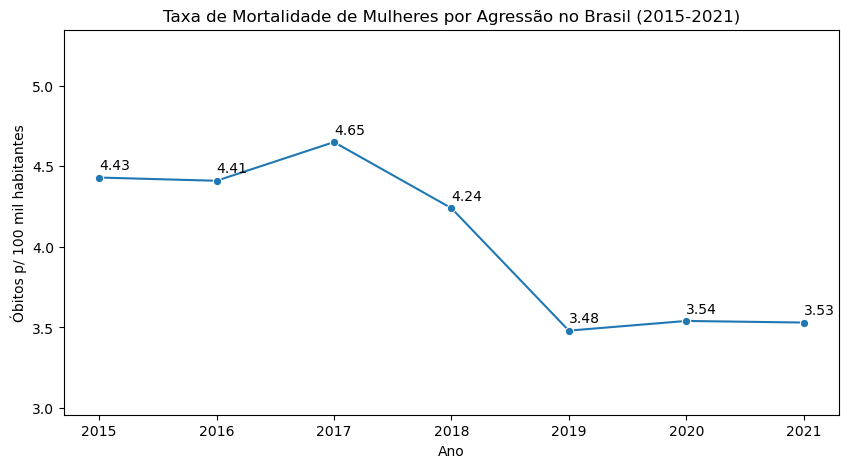

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
grafico_linha = sns.lineplot(
    data=evolucao_brasil, 
    x="ANO",
    y="TAXA_BRASIL",
    marker = "o",
    ax=ax,
)

grafico_linha.set(
    title="Taxa de Mortalidade de Mulheres por Agressão no Brasil (2015-2021)",
    xlabel="Ano", 
    ylabel="Óbitos p/ 100 mil habitantes",
    ylim=(evolucao_brasil["TAXA_BRASIL"].min() * 0.85, evolucao_brasil["TAXA_BRASIL"].max() * 1.15)
)

for indice, linha in evolucao_brasil.iterrows():

    grafico_linha.text(
        x=linha["ANO"],
        y=linha["TAXA_BRASIL"]
        + 0.05,
        s=f'{linha["TAXA_BRASIL"]:.2f}',
    )

fig.savefig(
    "outputs/taxa_mortalidade_brasil.png",
    dpi=300,
    bbox_inches="tight",
)
    
plt.show()


In [15]:
ranking_estado_historico = (
    tabela_unificada.groupby("ESTADO")[["OBITOS", "POPULACAO", "POP_FEMININA"]]
    .sum()
    .reset_index()
)

ranking_estado_historico["TAXA_ESTADO"] = calcular_taxa_100k(
    ranking_estado_historico["OBITOS"],
    ranking_estado_historico["POP_FEMININA"]
)

ranking_estado_historico = ranking_estado_historico.sort_values(
    by="TAXA_ESTADO", ascending=False
)

ranking_estado_historico


,ESTADO,OBITOS,POPULACAO,POP_FEMININA,TAXA_ESTADO
21,RR,222,4008753,2044461,10.86
5,CE,2194,63523992,32397232,6.77
0,AC,198,6002365,3061202,6.47
13,PA,1819,59398696,30293332,6.00
20,RO,372,12507823,6378986,5.83
7,ES,819,28083562,14322613,5.72
8,GO,1408,48344952,24655923,5.71
4,BA,3026,105425946,53767228,5.63
2,AM,811,28706534,14640330,5.54
19,RN,690,24505107,12497602,5.52


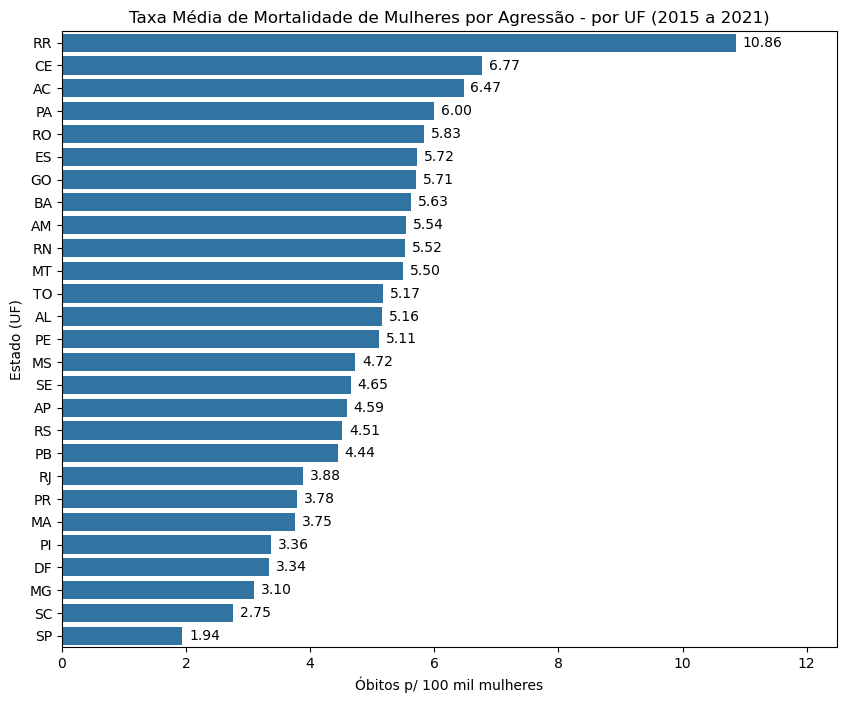

In [16]:
fig, ax = plt.subplots(figsize=(10,8))

grafico_barras = sns.barplot(
    data=ranking_estado_historico,
    x="TAXA_ESTADO",
    y="ESTADO",
    ax=ax
)

grafico_barras.set(
    title="Taxa Média de Mortalidade de Mulheres por Agressão - por UF (2015 a 2021)",
    xlabel="Óbitos p/ 100 mil mulheres",
    ylabel="Estado (UF)",
    xlim=(0, ranking_estado_historico["TAXA_ESTADO"].max() * 1.15)
)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=5
)

fig.savefig("outputs/taxa_mortalidade_estados.png",
    dpi=300,
    bbox_inches="tight")

plt.show()


In [17]:
# Variação entre pontos extremos do período — não captura oscilações intermediárias
df_pivot = tabela_unificada.pivot(index="ESTADO", columns="ANO", values="TAXA_POR_100K")
df_pivot["VARIACAO_PERCENTUAL"] = (
    ((df_pivot[2021] - df_pivot[2015]) / df_pivot[2015]) * 100
)
df_pivot["TENDENCIA"] = df_pivot["VARIACAO_PERCENTUAL"].apply(lambda x: "Piora (Aumento)" if x > 0  else "Melhora (Queda)")
tabela_variacao = df_pivot.sort_values(by="VARIACAO_PERCENTUAL", ascending=False)


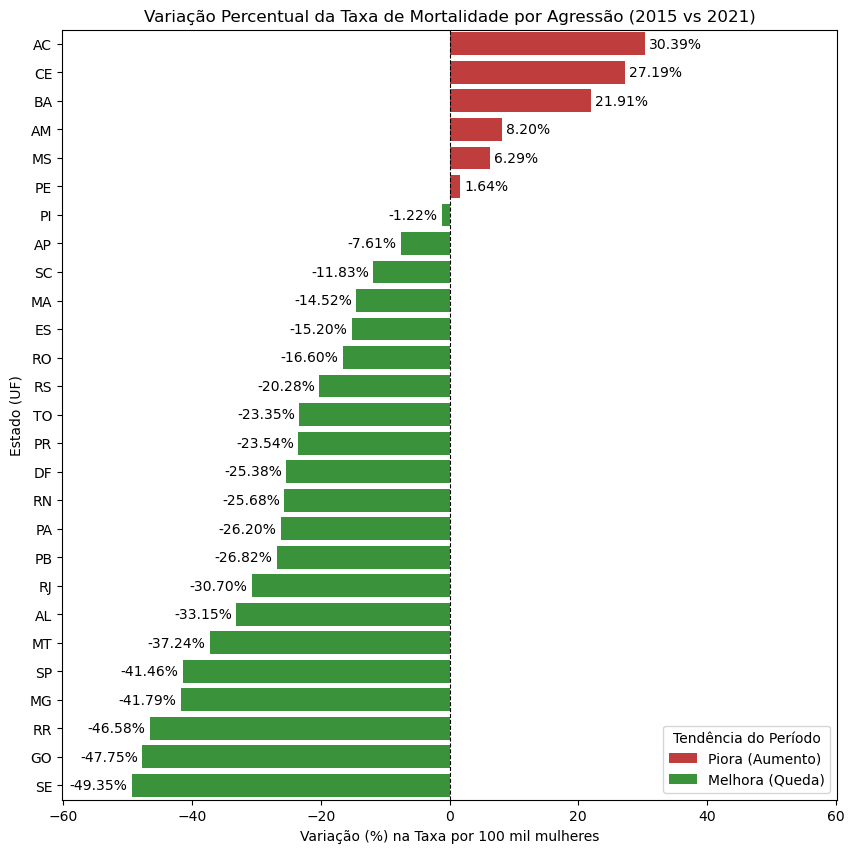

In [18]:
fig, ax = plt.subplots(figsize=(10, 10))

grafico_variacao = sns.barplot(
    data=tabela_variacao,
    x="VARIACAO_PERCENTUAL",
    y="ESTADO",
    hue="TENDENCIA",
    ax=ax,
    palette={
        "Piora (Aumento)": "#d62728",
        "Melhora (Queda)": "#2ca02c"
    }
)

limite = max(
    abs(tabela_variacao["VARIACAO_PERCENTUAL"].min()),
    abs(tabela_variacao["VARIACAO_PERCENTUAL"].max())
) * 1.22

grafico_variacao.set(
    title="Variação Percentual da Taxa de Mortalidade por Agressão (2015 vs 2021)",
    xlabel="Variação (%) na Taxa por 100 mil mulheres",
    ylabel="Estado (UF)",
    xlim=(-limite, limite)    
)

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

plt.legend(title="Tendência do Período", loc="lower right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

fig.savefig(
    "outputs/variacao_mortalidade_uf_2015_2021.png",
    dpi=300,
    bbox_inches="tight")


plt.show()


---

## 5. Síntese Analítica e Conclusões Executivas

A modelagem de dados da série histórica revela discrepâncias relevantes entre o comportamento da média nacional e a realidade regional da violência letal contra a mulher no Brasil.

### 1. Descolamento Nacional vs. Estadual
* O indicador consolidado do Brasil sugere uma transição favorável de queda na mortalidade feminina por agressão no intervalo analisado.
* **Redução majoritária:** Das 27 Unidades da Federação, **21 estados (77,7%)** registraram queda em suas taxas. O topo da tabela de melhorias é liderado por **Sergipe (-49,36%)**, **Goiás (-47,93%)** e **Roraima (-46,69%)**, que reduziram praticamente pela metade seus índices letais.

### 2. Identificação de Bolsões Críticos
* Em sentido oposto à média do país, **6 estados (22,3%)** apresentaram **crescimento percentual** na mortalidade feminina por agressão entre 2015 e 2021.
* A deterioração do indicador concentra-se majoritariamente em estados das regiões Norte e Nordeste, com as maiores variações sendo:
  * **Acre (AC):** +30,93%
  * **Ceará (CE):** +27,37%
  * **Bahia (BA):** +21,91%
  * **Amazonas (AM):** +8,22%

### 3. Considerações para Tomada de Decisão
Os dados evidenciam que abordagens padronizadas em nível federal são insuficientes para tratar a violência contra a mulher, visto que a média nacional em queda mascara o agravamento severo do cenário em estados específicos. A alocação de recursos públicos, estratégias preventivas e inteligência policial devem ser direcionadas com urgência para o recrudescimento observado em estados como Acre, Ceará e Bahia.

## Machine Learning — Clusterização K-Means

Agrupamento dos estados por perfil de mortalidade usando K-Means. O número ideal de clusters foi determinado pelo Método do Cotovelo.

In [19]:
df_ml_base = tabela_variacao.reset_index()


In [20]:
df_ml_base = df_ml_base[["ESTADO", 2015, 2021]]
df_ml_base.head()


ANO,ESTADO,2015,2021
0,AC,4.64,6.05
1,CE,5.59,7.11
2,BA,4.93,6.01
3,AM,5.73,6.20
4,MS,4.29,4.56


In [21]:
df_ml = pd.merge(df_ml_base, ranking_estado_historico[["ESTADO", "TAXA_ESTADO"]], on="ESTADO")
df_ml = df_ml.rename(columns={2015: "TAXA_2015", 2021: "TAXA_2021"})

df_ml.head()


,ESTADO,TAXA_2015,TAXA_2021,TAXA_ESTADO
0,AC,4.64,6.05,6.47
1,CE,5.59,7.11,6.77
2,BA,4.93,6.01,5.63
3,AM,5.73,6.20,5.54
4,MS,4.29,4.56,4.72


In [22]:
features = df_ml[["TAXA_ESTADO", "TAXA_2015", "TAXA_2021"]]
features.head()


,TAXA_ESTADO,TAXA_2015,TAXA_2021
0,6.47,4.64,6.05
1,6.77,5.59,7.11
2,5.63,4.93,6.01
3,5.54,5.73,6.20
4,4.72,4.29,4.56


In [23]:
# Padroniza as variáveis (média 0 e desvio padrão 1) 
# Isso é crucial para o K-Means, pois ele calcula distâncias geométricas (Euclidiana) 
# e variáveis em escalas diferentes distorceriam os clusters
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print(features_scaled)


[[ 0.9256299  -0.42222376  1.28446351]
 [ 1.10899018  0.13950028  2.06945915]
 [ 0.41222109 -0.25075011  1.25484103]
 [ 0.357213    0.22228066  1.3955478 ]
 [-0.14397178 -0.62917472  0.18102625]
 [ 0.09439659 -0.27440164  0.48465663]
 [-0.97520508 -0.74151953 -0.19666033]
 [-0.22342791 -0.4458753  -0.04854795]
 [-1.34803767 -1.51610741 -1.37415379]
 [-0.73683671 -0.68239068 -0.53731882]
 [ 0.46722918  0.99686855  1.22521856]
 [ 0.53446128  0.96730412  1.12153989]
 [-0.27232398 -0.25075011 -0.28552776]
 [ 0.13106865  0.50609912  0.32913863]
 [-0.71850068 -0.62917472 -0.76689301]
 [-0.9874291  -0.85977722 -1.04090092]
 [ 0.34498899 -0.10292799 -0.34477272]
 [ 0.63836545  0.53566355  0.22545996]
 [-0.31510805  0.07445855 -0.22628281]
 [-0.65738059 -0.46952684 -0.85576044]
 [ 0.12495664  0.13358739 -0.43364015]
 [ 0.33276497  1.02643297  0.09956444]
 [-1.84311044 -1.7112326  -2.12952695]
 [-1.13411733 -0.85977722 -1.51486055]
 [ 3.6088021   3.48619296  1.25484103]
 [ 0.46111717  1.30433855

### Método do Cotovelo

Teste de K de 1 a 10 para identificar o ponto onde adicionar mais clusters deixa de reduzir significativamente a inércia.

In [24]:
inertias = []
for k in range(1, 11):
     kmeans = KMeans(n_clusters=k, n_init=10)
     kmeans.fit(features_scaled)
     inertias.append(kmeans.inertia_)

print(inertias)



[81.00000000000001, 42.020390631570635, 24.431783044623465, 14.454827612750282, 10.34113385824086, 7.555245735916004, 5.965304932427789, 4.792354218048942, 4.098350213705151, 3.2245988398599303]


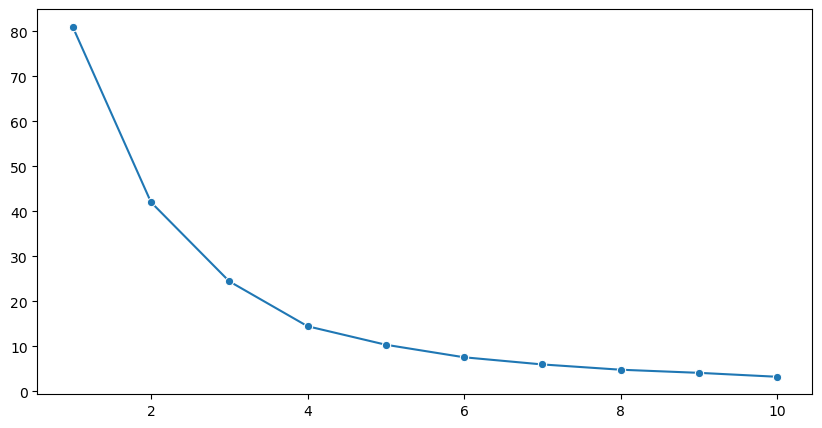

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
grafico_linha_kmeans = sns.lineplot(
    x=range(1,11),
    y=inertias,
    ax=ax,
    marker="o"
)
plt.show()


In [26]:
# Treina o modelo final com K=5 (definido pelo Método do Cotovelo)
# O random_state=42 garante que os resultados sejam sempre os mesmos (reprodutibilidade)
kmeans_final = KMeans(n_clusters=5, n_init=10, random_state=42).fit(features_scaled)

df_ml["cluster"] = kmeans_final.labels_
print(df_ml[["ESTADO", "cluster"]].sort_values("cluster"))

   ESTADO  cluster
26     SE        0
20     AL        0
19     RJ        0
18     PB        0
4      MS        0
5      PE        0
6      PI        0
7      AP        0
16     RN        0
9      MA        0
14     PR        0
12     RS        0
0      AC        1
3      AM        1
2      BA        1
1      CE        1
25     GO        2
10     ES        2
17     PA        2
21     MT        2
11     RO        2
13     TO        2
24     RR        3
15     DF        4
8      SC        4
22     SP        4
23     MG        4


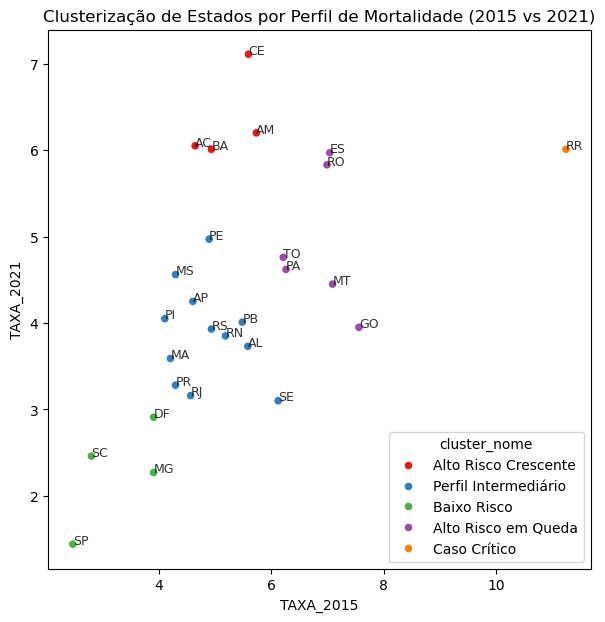

In [27]:
nomes_clusters = {
    0: "Perfil Intermediário",
    1: "Alto Risco Crescente",
    2: "Alto Risco em Queda",
    3: "Caso Crítico",
    4: "Baixo Risco"
}

df_ml["cluster_nome"] = df_ml["cluster"].map(nomes_clusters)

fig, ax = plt.subplots(figsize=(7, 7))
scatter_plot = sns.scatterplot(
    data=df_ml,
    x="TAXA_2015",
    y="TAXA_2021",
    ax=ax,
    hue="cluster_nome",
    palette="Set1"
)

# Itera sobre cada linha do dataframe para extrair as coordenadas X e Y 
# e adiciona o texto (nome do estado/taxa) exatamente na posição do ponto
for indice, linha in df_ml.iterrows():

    scatter_plot.text(
        x=linha["TAXA_2015"],
        y=linha["TAXA_2021"],
        s=linha["ESTADO"],
        fontsize=9,
        alpha=0.8,
    )

scatter_plot.set(title="Clusterização de Estados por Perfil de Mortalidade (2015 vs 2021)")

fig.savefig("outputs/cluster_estados.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

In [28]:
perfil_clusters = (
    df_ml.groupby("cluster_nome")[["TAXA_2015", "TAXA_2021", "TAXA_ESTADO"]]
    .mean()
)
display(perfil_clusters.head())

,TAXA_2015,TAXA_2021,TAXA_ESTADO
cluster_nome,,,
Alto Risco Crescente,5.222500,6.342500,6.102500
Alto Risco em Queda,6.858333,4.930000,5.655000
Baixo Risco,3.262500,2.270000,2.782500
Caso Crítico,11.250000,6.010000,10.860000
Perfil Intermediário,4.851667,3.873333,4.455833


In [29]:
X = evolucao_brasil[["ANO"]]
y = evolucao_brasil["TAXA_BRASIL"]
modelo = LinearRegression()
modelo.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.2]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['ANO']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,408.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [30]:
print(modelo.coef_)
print(modelo.intercept_)

[-0.20035714]
408.3607142857144


In [31]:
evolucao_brasil["PREVISAO"] = modelo.predict(X)

In [32]:
print(evolucao_brasil)

    ANO  OBITOS  POPULACAO  POP_FEMININA  TAXA_BRASIL  PREVISAO
0  2015    4616  204450049     104269513         4.43  4.641071
1  2016    4635  206081432     105101519         4.41  4.440714
2  2017    4928  207660929     105907059         4.65  4.240357
3  2018    4512  208494900     106332383         4.24  4.040000
4  2019    3728  210147125     107175018         3.48  3.839643
5  2020    3822  211755692     107995389         3.54  3.639286
6  2021    3844  213317639     108791981         3.53  3.438929


In [33]:
anos_futuros = pd.DataFrame({"ANO": [2022, 2023]})
previsoes = modelo.predict(anos_futuros)
print(previsoes)

[3.23857143 3.03821429]


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
grafico_linear_regressao = sns.lineplot(
    data=evolucao_brasil,
    x="ANO",
    y="PREVISAO",
    linestyle="--",
    color="gray",
    label="Tendência (Regressão Linear)",
    ax=ax,
)
grafico_real = sns.lineplot(
    data=evolucao_brasil,
    x="ANO",
    y="TAXA_BRASIL",
    marker="o",
    label="Taxa Real",
    ax=ax
)
grafico_real.set(
    title="Taxa de Mortalidade Nacional: Real vs Tendencia (2015-2021)",
    ylabel="Óbitos por 100mil mulheres"
)
plt.legend()
plt.show()